In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/My Drive/Crime Analysis')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [ ]:
!pip install japanize-matplotlib --quiet
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Subregions dataframe
import geopandas as gpd

def convert_kanji_to_num(s):
    if pd.isna(s):
        return s
    return s.replace('〇', '０').replace('一', '１').replace('二', '２').replace('三', '３').replace('四', '４').replace('五', '５').replace('六', '６').replace('七', '７').replace('八', '８').replace('九', '９')

subregions = gpd.read_file('data/subregions.geojson')
subregions = subregions.to_crs(epsg=4326)
subregions['市区町丁'] = subregions.apply(lambda row: f"{row['CITY_NAME']}{convert_kanji_to_num(row['S_NAME'])}", axis=1)

In [ ]:
# Subregions graph
import pickle

with open('data/subregions_graph.pkl', 'rb') as f:
    G = pickle.load(f)

In [ ]:
# Region-based dataframe
region_df = pd.read_csv('data/region/region_2022.csv')

In [ ]:
df = pd.DataFrame()

In [ ]:
for filename in os.listdir('data/case'):
    if filename.endswith('.csv'):
        df = pd.concat([df, pd.read_csv('data/case/' + filename)])
df['発生年月日（始期）'] = pd.to_datetime(df['発生年月日（始期）'], errors='coerce')
df['市区町丁'] = df.apply(lambda x: str(x['市区町村（発生地）']) + str(x['町丁目（発生地）']), axis=1)

## Filtering

In [ ]:
select_regions = ['渋谷区', '新宿区', '豊島区']
region_df_filtered = region_df[region_df['市区町丁'].str.contains('|'.join(select_regions))]
print('Number of neighborhoods:', region_df_filtered.shape[0])

Number of neighborhoods: 310


In [ ]:
subregions_filtered = subregions[subregions['市区町丁'].str.contains('|'.join(select_regions))]
G_filtered = G.subgraph(subregions_filtered.index)
G_filtered = nx.relabel_nodes(G, { n: G.nodes[n]['市区町丁'] for n in G.nodes })
print(f'Considering {len(G_filtered.nodes)} nodes')
print(f'Considering {round(len(G_filtered.nodes) / len(G.nodes) * 100, 2)}% of nodes')

Considering 5526 nodes
Considering 91.78% of nodes


In [ ]:
region_df_filtered = region_df_filtered.set_index('市区町丁', drop=False).loc[list(set(region_df_filtered['市区町丁']).intersection(set(subregions_filtered['市区町丁'])))]
print('Number of neighborhoods that are on the graph:', len(region_df_filtered))

Number of neighborhoods that are on the graph: 280


In [ ]:
df_filtered = df[df['市区町丁'].isin(subregions_filtered['市区町丁'])]

In [ ]:
common_regions = list(set(region_df_filtered['市区町丁']).intersection(set(df_filtered['市区町丁'])))
print('Neighborhoods that have case data published:', len(common_regions), 'of', len(region_df_filtered))

Neighborhoods that have case data published: 239 of 280


In [ ]:
noncommon_regions = list(set(region_df_filtered['市区町丁']).difference(set(df_filtered['市区町丁'])))
print('Neighborhoods that have no case data published:', len(noncommon_regions))

Neighborhoods that have no case data published: 41


In [ ]:
# Overwriting for shorter variable names
region_df = region_df_filtered
subregions = subregions_filtered
G = G_filtered
df = df_filtered

In [ ]:
from datetime import timedelta

ts_df = df.groupby(['市区町丁', df['発生年月日（始期）'].dt.date]).size().unstack(fill_value=0)
ts_2022 = ts_df[[col for col in ts_df.columns if col.year == 2022]].reindex(common_regions).dropna(how='all')
ts_2022 = ts_2022.T
start_date = ts_2022.index.min()
end_date = ts_2022.index.max() + timedelta(days=1) # for the 365 days
full_range = pd.date_range(start=start_date, end=end_date, freq='D')
ts_2022 = ts_2022.reindex(full_range)
ts_2022 = ts_2022.fillna(0)
ts_2022[noncommon_regions] = 0

In [ ]:
assert set(list(ts_2022.columns)) == set(list(region_df['市区町丁'])) and len(list(ts_2022.columns)) == len(list(region_df['市区町丁']))

In [ ]:
from scipy.signal import butter, filtfilt

# Low-pass filter
b, a = butter(3, 0.1)
low_pass = lambda y: filtfilt(b, a, y)

def relu(x):
    return np.maximum(0, x)

def lpfilter_and_scale(col):
    factor = region_df.set_index('市区町丁').loc[col.name, '非侵入窃盗計']
    if col.sum() > 0:
        col = low_pass(col)
        col = (col - col.min()) / (col.max() - col.min())
        col *= factor / col.sum()
        return relu(col)
    else:
        col = np.ones(len(col)) * (factor / len(col)) # Make all values uniform, but still aggregate to "factor"
        return col

ts_2022_filtered = ts_2022.apply(lpfilter_and_scale, axis=0)
print('Number of columns that are still zeros:', ts_2022_filtered.apply(lambda x: x.sum() == 0).sum())

Number of columns that are still zeros: 19


<Axes: >

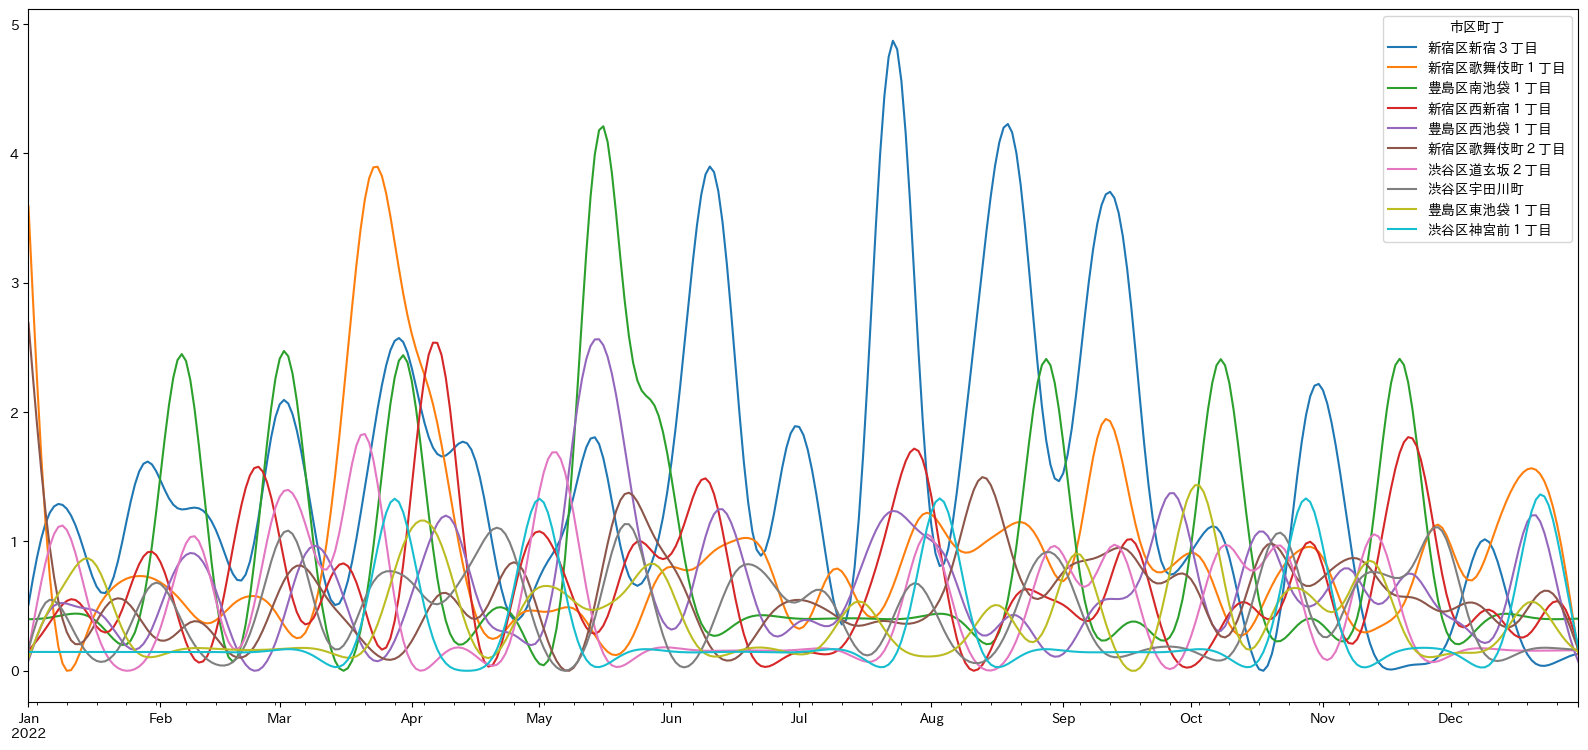

In [ ]:
ts_2022_filtered[ts_2022_filtered.sum().sort_values(ascending=False).index[:10]].plot(figsize=(20, 9))

In [ ]:
G_filtered = G.subgraph(ts_2022_filtered.columns)
assert set([G_filtered.nodes[node]['市区町丁'] for node in G_filtered.nodes]) == set(list(ts_2022.columns))

In [ ]:
for node in G_filtered.nodes:
    if ts_2022[node].sum() > 0:
        G_filtered.nodes[node]['original_series'] = ((ts_2022[node] - ts_2022[node].min()) / (ts_2022[node].max() - ts_2022[node].min()))
        G_filtered.nodes[node]['original_series'] *= (region_df_filtered.loc[node, '非侵入窃盗計'] / G_filtered.nodes[node]['original_series'].sum())
    else:
        G_filtered.nodes[node]['original_series'] = np.ones(365) * (region_df_filtered.loc[node, '非侵入窃盗計'] / 365)
    G_filtered.nodes[node]['time_series'] = ts_2022_filtered[node].values
    G_filtered.nodes[node]['influenced_series'] = np.zeros(365)

In [ ]:
from scipy.optimize import minimize

def get_neighbors_within_distance(G, node, max_distance):
    """
    Get nodes within a given maximum distance from a specific node.
    """
    return nx.single_source_shortest_path_length(G, node, cutoff=max_distance)

def predict_series(node, lambda_value, G, num_days, max_distance):
    """
    Predict the time series for a node based on exponential influence from its neighbors.
    """
    distance_dict = get_neighbors_within_distance(G, node, max_distance)
    predicted_series = np.zeros(num_days)
    center_value = G.nodes[node]['original_series']
    predicted_dict = {}

    for neighbor, distance in distance_dict.items():
        if 'original_series' in G.nodes[neighbor]:
            influence = lambda_value * np.exp(-lambda_value * distance)
            predicted_series += (influence * G.nodes[neighbor]['time_series'])
            predicted_dict[neighbor] = ((influence - 1) * G.nodes[neighbor]['time_series'])

    return predicted_series, predicted_dict

def objective_function(lambda_value, node, G, num_days, max_distance):
    """
    Objective function to minimize the MSE between the original series and the influenced series.
    """
    influenced_series, _ = predict_series(node, lambda_value, G, num_days, max_distance)
    original_series = G.nodes[node]['original_series']
    mse = np.mean((original_series - influenced_series) ** 2)
    return mse

def optimize_lambda(node, G, num_days, max_distance):
    """
    Optimize lambda to minimize the MSE between the original series and the influenced series.
    """
    initial_lambda = 0.1
    result = minimize(objective_function, initial_lambda, args=(node, G, num_days, max_distance), bounds=[(0, None)])
    return result.x[0]

In [ ]:
num_days = 365
max_distance = 3

predict_dicts = {}

for node in G_filtered.nodes:
    lambda_value = optimize_lambda(node, G_filtered, num_days, max_distance)
    G_filtered.nodes[node]['lambda'] = lambda_value
    G_filtered.nodes[node]['influenced_series'], predict_dict = predict_series(node, lambda_value, G_filtered, num_days, max_distance)
    predict_dicts[node] = predict_dict
    print(f'{node}: {lambda_value}')

渋谷区広尾５丁目: 2.631538870697599
豊島区駒込３丁目: 0.07476866457157766
新宿区西新宿１丁目: 0.14397530611294163
豊島区東池袋２丁目: 0.02091931095950072
豊島区西池袋３丁目: 0.03532687256107957
新宿区市谷薬王寺町: 0.008579401173415038
豊島区西巣鴨１丁目: 0.010525459226155364
豊島区駒込５丁目: 0.003902243662454381
豊島区上池袋２丁目: 0.010430269054372207
豊島区目白４丁目: 0.0032399499951382272
新宿区百人町４丁目: 0.013304359093272052
新宿区市谷田町２丁目: 3.754828933031415
豊島区千早４丁目: 0.02486601976574524
新宿区下落合２丁目: 0.005938766662936381
新宿区市谷甲良町: 0.009807557365125475
渋谷区笹塚２丁目: 0.5353858983065332
豊島区西巣鴨４丁目: 0.02702098506233175
渋谷区本町５丁目: 1.4745948221818288
豊島区駒込６丁目: 0.012723773183557451
新宿区神楽坂４丁目: 0.0
渋谷区恵比寿３丁目: 0.06506466477244653
新宿区西落合１丁目: 0.1108314913019266
新宿区西早稲田２丁目: 0.0383581717921341
新宿区揚場町: 3.776940446668312
新宿区荒木町: 2.379096177560453
渋谷区恵比寿西２丁目: 0.01037249677316177
新宿区市谷台町: 0.05780199118619777
渋谷区初台２丁目: 0.0008066395865929931
豊島区巣鴨４丁目: 0.019645131985523936
渋谷区西原２丁目: 0.10390567233118705
豊島区南長崎５丁目: 0.09052476782572973
豊島区南長崎６丁目: 0.023234639897346233
新宿区中井１丁目: 0.016160257455913457
豊島区巣鴨２丁目

In [ ]:
from datetime import datetime, timedelta
start_date = datetime(2022, 1, 1)
end_date = datetime(2022, 12, 31)
dates = [(start_date + timedelta(days=i)).strftime('%Y-%m-%d') for i in range((end_date - start_date).days + 1)]

node_data = []
node_ids = []

for node in G_filtered.nodes:
    node_info = {
        'node': node,
        'influenced_series': G_filtered.nodes[node].get('influenced_series', np.zeros(365))
    }
    node_ids.append(node_info['node'])
    node_data.append(node_info['influenced_series'])

node_influenced_series_df = pd.DataFrame(node_data, index=node_ids, columns=dates)
node_influenced_series_df.reset_index(inplace=True)
node_influenced_series_df.rename(columns={'index': '市区町丁'}, inplace=True)

In [ ]:
import folium
from folium.plugins import HeatMap
from folium import Choropleth
from matplotlib import cm, colors, colormaps
from matplotlib.colors import LinearSegmentedColormap

class HeatmapBase:
    def __init__(self, df, weight_col=None, zoom_start=12, colormap=None):
        self.df = pd.merge(df, subregions[['市区町丁', 'geometry']], on='市区町丁', how='left')
        self.df = self.df[~self.df['geometry'].isna()]
        self.weight_col = weight_col
        self.zoom_start = zoom_start

        combined_geometry = gpd.GeoSeries(self.df['geometry']).unary_union
        self.centroid = combined_geometry.centroid
        self.m = folium.Map(location=[self.centroid.y, self.centroid.x], zoom_start=self.zoom_start, tiles='cartodbpositron')
        self.colormap = colormap if colormap is not None else LinearSegmentedColormap.from_list('green_yellow_red', ['green', 'yellow', 'red'])
        # self.m = folium.Map(location=[35.682839, 139.759455], zoom_start=12, tiles='cartodbpositron')

    def render(self):
        if self.weight_col is not None:
            norm = colors.Normalize(vmin=self.df[self.weight_col].min(), vmax=self.df[self.weight_col].max())
            # cmap = colormaps.get_cmap('viridis')
            cmap = self.colormap

        for _, row in self.df.iterrows():
            if row['geometry'] is not None:
                if self.weight_col is not None:
                    color = colors.to_hex(cmap(norm(row[self.weight_col])))
                else:
                    color = '#3186cc'  # Default color when weight_col is None

                folium.GeoJson(
                    row['geometry'].__geo_interface__,
                    style_function=lambda _, color=color: {
                        'fillColor': color,
                        'color': None,
                        'weight': 0,
                        'fillOpacity': 0.7
                    }
                ).add_to(self.m)

        return self.m

    def reset_map(self):
        self.m = folium.Map(location=[self.centroid.y, self.centroid.x], zoom_start=self.zoom_start, tiles='cartodbpositron')

In [ ]:
HeatmapBase(node_influenced_series_df, weight_col='2022-08-29', zoom_start=13).render()

In [ ]:
HeatmapBase(node_influenced_series_df, weight_col='2022-08-29', zoom_start=13).render().save('final_data/index.html')

In [ ]:
col_name = '新宿区新宿３丁目'

In [ ]:
all_columns = set()
for sub_dict in predict_dicts.values():
    all_columns.update(sub_dict.keys())

normalized_data = {}
for node, sub_dict in predict_dicts.items():
    normalized_data[node] = {}
    max_len = max(map(len, sub_dict.values()))
    for col in all_columns:
        normalized_data[node][col] = sub_dict.get(col, [0] * max_len)

df_list = []
for node, sub_dict in normalized_data.items():
    df_temp = pd.DataFrame(sub_dict)
    df_temp.index = [node] * len(df_temp)
    df_list.append(df_temp)

predict_df = pd.concat(df_list)

In [ ]:
# Turn this into a dataframe when the place is called, and then use that for the heatmap
predict_dicts['新宿区新宿３丁目']

{'新宿区新宿３丁目': array([-0.13054413, -0.17952559, -0.22355715, -0.26109649, -0.29075413,
        -0.31179924, -0.32437265, -0.32926369, -0.32744492, -0.31968899,
        -0.30644584, -0.28801373, -0.26496181, -0.2386187 , -0.21129779,
        -0.18606445, -0.16619285, -0.15459809, -0.15339312, -0.16358721,
        -0.18491567, -0.21580035, -0.2534511 , -0.29412848, -0.33359689,
        -0.36776882, -0.39340556, -0.40860029, -0.41290293, -0.40724951,
        -0.39384917, -0.37589569, -0.35696125, -0.34023387, -0.32789403,
        -0.3207862 , -0.31840475, -0.31918217, -0.32103773, -0.32201027,
        -0.32066342, -0.31609116, -0.30769618, -0.29504997, -0.27800231,
        -0.25703139, -0.23364881, -0.21053208, -0.19119144, -0.17932243,
        -0.17813413, -0.18980906, -0.21511958, -0.25320119, -0.30149499,
        -0.35588439, -0.41106246, -0.46117565, -0.50076057, -0.52581786,
        -0.53458613, -0.52756954, -0.50684286, -0.47512689, -0.43511223,
        -0.38921962, -0.33976697, -0.28

In [ ]:
predict_df = predict_df.fillna(0)
predict_df = predict_df.applymap(lambda x: 0.0 if x == -0.0 else x)

<ipython-input-31-05818b93ca47>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  predict_df = predict_df.applymap(lambda x: 0.0 if x == -0.0 else x)


In [ ]:
(predict_df[col_name] > 0).sum()

0

In [ ]:
len(get_neighbors_within_distance(G_filtered, col_name, max_distance).keys())

28

In [ ]:
class HeatmapNode(HeatmapBase):
    def __init__(self, node, weight_col=None, zoom_start=12):
        neighbor_keys = list(predict_dicts[node].keys())
        df = pd.DataFrame([predict_dicts[node][key] for key in neighbor_keys], index=neighbor_keys, columns=pd.date_range('2022-01-01', periods=365, freq='D').strftime('%Y-%m-%d'))
        df = df.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)
        df = df.apply(lambda x: x ** 10)
        df = df.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

        df = df.reset_index(drop=False).rename(columns={ 'index': '市区町丁' })

        self.node = node
        self.colormap = LinearSegmentedColormap.from_list('white_yellow_blue', ['#f1c40f', '#e74c3c'])
        super().__init__(df, weight_col=weight_col, zoom_start=zoom_start, colormap=self.colormap)

In [ ]:
HeatmapNode('豊島区南池袋１丁目', weight_col='2022-01-01', zoom_start=13).render()

In [ ]:
node = '新宿区新宿３丁目'
neighbor_keys = list(predict_dicts[node].keys())
pd.DataFrame([predict_dicts[node][key] for key in neighbor_keys], index=neighbor_keys, columns=pd.date_range('2022-01-01', periods=365, freq='D').strftime('%Y-%m-%d')).reset_index(drop=False)

,index,2022-01-01,2022-01-02,2022-01-03,2022-01-04,2022-01-05,2022-01-06,2022-01-07,2022-01-08,2022-01-09,...,2022-12-22,2022-12-23,2022-12-24,2022-12-25,2022-12-26,2022-12-27,2022-12-28,2022-12-29,2022-12-30,2022-12-31
0,新宿区新宿３丁目,-0.130544,-0.179526,-0.223557,-0.261096,-0.290754,-0.311799,-0.324373,-0.329264,-0.327445,...,-0.010173,-0.009650,-0.011275,-0.014299,-0.018065,-0.022038,-0.025815,-0.029130,-0.031832,-0.033872
1,新宿区内藤町,-0.004874,-0.016382,-0.027033,-0.036034,-0.042729,-0.046693,-0.047805,-0.046280,-0.042595,...,-0.005473,-0.005405,-0.005310,-0.005202,-0.005094,-0.004996,-0.004912,-0.004846,-0.004798,-0.004767
2,新宿区新宿２丁目,-0.025753,-0.050286,-0.073961,-0.096142,-0.116121,-0.133109,-0.146303,-0.155032,-0.158992,...,-0.153577,-0.145875,-0.133701,-0.118429,-0.101489,-0.084156,-0.067425,-0.051964,-0.038118,-0.025963
3,新宿区新宿４丁目,-0.047987,-0.047987,-0.047987,-0.047987,-0.047987,-0.047987,-0.047987,-0.047987,-0.047987,...,-0.047976,-0.047975,-0.047976,-0.047977,-0.047978,-0.047980,-0.047982,-0.047984,-0.047985,-0.047987
4,新宿区新宿５丁目,-0.020883,-0.021181,-0.021485,-0.021763,-0.021973,-0.022068,-0.021994,-0.021699,-0.021138,...,-0.013705,-0.011935,-0.011407,-0.011813,-0.012853,-0.014257,-0.015803,-0.017318,-0.018684,-0.019831
5,新宿区西新宿１丁目,-0.100344,-0.125546,-0.151708,-0.179692,-0.209801,-0.241598,-0.273809,-0.304342,-0.330462,...,-0.258089,-0.292248,-0.322081,-0.342313,-0.348121,-0.336007,-0.304631,-0.255236,-0.191401,-0.118331
6,新宿区新宿１丁目,-0.032707,-0.041944,-0.051571,-0.061936,-0.073184,-0.085184,-0.097488,-0.109338,-0.119722,...,-0.034709,-0.034293,-0.033718,-0.033077,-0.032441,-0.031861,-0.031373,-0.030990,-0.030715,-0.030540
7,新宿区歌舞伎町１丁目,-2.987552,-2.418825,-1.876965,-1.384158,-0.957833,-0.609245,-0.343068,-0.157839,-0.046963,...,-1.266096,-1.218865,-1.149259,-1.055664,-0.938079,-0.798430,-0.640213,-0.467986,-0.287171,-0.104047
8,新宿区歌舞伎町２丁目,-2.237198,-1.905634,-1.586274,-1.290129,-1.025125,-0.795920,-0.604403,-0.450427,-0.332559,...,-0.501424,-0.515242,-0.513606,-0.495468,-0.461217,-0.412609,-0.352404,-0.283832,-0.210158,-0.134441
9,新宿区富久町,-0.016439,-0.016621,-0.016839,-0.017082,-0.017330,-0.017557,-0.017729,-0.017807,-0.017746,...,-0.016393,-0.016380,-0.016369,-0.016360,-0.016354,-0.016349,-0.016347,-0.016346,-0.016346,-0.016348


In [ ]:
# node_influenced_series_df.to_csv('final_data/influenced_series.csv', index=False)
# with open('final_data/graph.pkl', 'wb') as f:
#     pickle.dump(G_filtered, f)
# with open('final_data/predict_dicts.pkl', 'wb') as f:
#     pickle.dump(predict_dicts, f)

In [ ]:
df

,罪名,手口,管轄警察署（発生地）,管轄交番・駐在所（発生地）,市区町村コード（発生地）,都道府県（発生地）,市区町村（発生地）,町丁目（発生地）,発生年月日（始期）,発生時（始期）,...,latitude,longitude,police_office_name,police_office_latitude,police_office_longitude,盗難防止装置の有無,現金以外の主な被害品,被害者の性別,現金被害の有無,市区町丁
4672,窃盗,自転車盗,渋谷,代官山交番,131130.0,東京都,渋谷区,猿楽町,2022-06-18,10,...,35.650102,139.701132,渋谷警察署 代官山交番,35.647257,139.701771,NaN,NaN,NaN,NaN,渋谷区猿楽町
4673,窃盗,自転車盗,渋谷,代官山交番,131130.0,東京都,渋谷区,代官山町,2022-09-26,16,...,35.650732,139.704675,渋谷警察署 代官山交番,35.647257,139.701771,NaN,NaN,NaN,NaN,渋谷区代官山町
4674,窃盗,自転車盗,渋谷,代官山交番,131130.0,東京都,渋谷区,代官山町,2022-11-06,1,...,35.650732,139.704675,渋谷警察署 代官山交番,35.647257,139.701771,NaN,NaN,NaN,NaN,渋谷区代官山町
4675,窃盗,自転車盗,渋谷,代官山交番,131130.0,東京都,渋谷区,代官山町,2022-11-11,12,...,35.650732,139.704675,渋谷警察署 代官山交番,35.647257,139.701771,NaN,NaN,NaN,NaN,渋谷区代官山町
4676,窃盗,自転車盗,渋谷,宇田川交番,131130.0,東京都,渋谷区,宇田川町,2022-01-31,11,...,35.662075,139.697496,渋谷警察署 宇田川交番,NaN,NaN,NaN,NaN,NaN,NaN,渋谷区宇田川町
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49,窃盗,自動販売機ねらい,巣鴨,大塚駅前交番,131164.0,東京都,豊島区,南大塚３丁目,NaT,17,...,35.729060,139.727495,巣鴨警察署 大塚駅前交番,35.731256,139.729277,NaN,NaN,NaN,あり,豊島区南大塚３丁目
50,窃盗,自動販売機ねらい,巣鴨,巣鴨新田交番,131164.0,東京都,豊島区,上池袋１丁目,NaT,9,...,35.736015,139.722431,巣鴨警察署 巣鴨新田交番,35.736385,139.725094,NaN,NaN,NaN,あり,豊島区上池袋１丁目
51,窃盗,自動販売機ねらい,巣鴨,巣鴨駅前交番,131164.0,東京都,豊島区,巣鴨３丁目,NaT,20,...,35.734110,139.735352,巣鴨警察署 巣鴨駅前交番,35.733657,139.738838,NaN,NaN,NaN,あり,豊島区巣鴨３丁目
52,窃盗,自動販売機ねらい,池袋,池袋駅西口交番,131164.0,東京都,豊島区,西池袋１丁目,NaT,17,...,35.730165,139.709385,池袋警察署 池袋駅西口交番,NaN,NaN,NaN,NaN,NaN,あり,豊島区西池袋１丁目


In [ ]:
df['発生時（始期）'] = pd.to_numeric(df['発生時（始期）'], errors='coerce')
df = df.dropna(subset=['発生時（始期）'])
df['発生時（始期）'] = df['発生時（始期）'].astype(int)
time_grouped = df.groupby(['市区町丁', '発生時（始期）']).size().unstack(fill_value=0)

<ipython-input-48-0d24df74057a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['発生時（始期）'] = df['発生時（始期）'].astype(int)


In [ ]:
missing_regions = list(set(list(region_df['市区町丁'])).difference(set(list(time_grouped.index))))
time_grouped = time_grouped.reindex(time_grouped.index.tolist() + missing_regions, fill_value=0)
assert set(time_grouped.index) == set(region_df['市区町丁'])

In [ ]:
time_grouped.to_csv('final_data/time_grouped.csv', index=True)

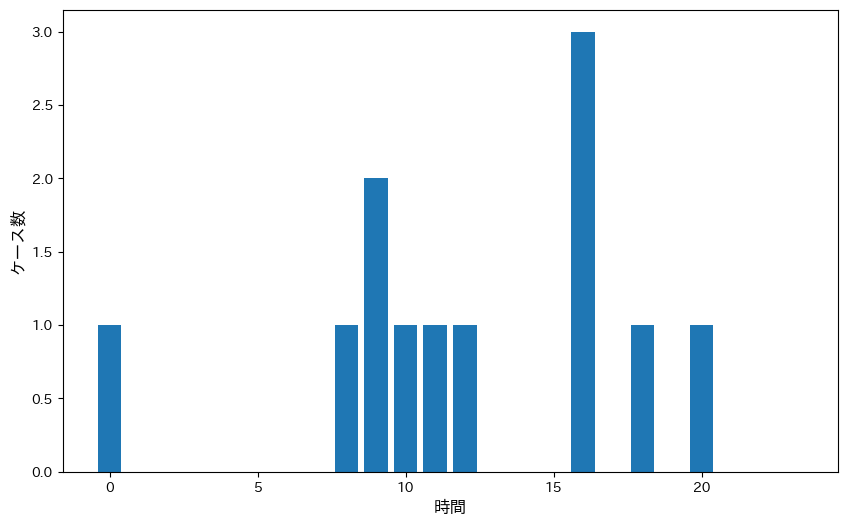

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(time_grouped.columns, time_grouped.iloc[0].astype(int))
plt.xlabel('時間', fontsize=12)
plt.ylabel('ケース数', fontsize=12)
plt.show()

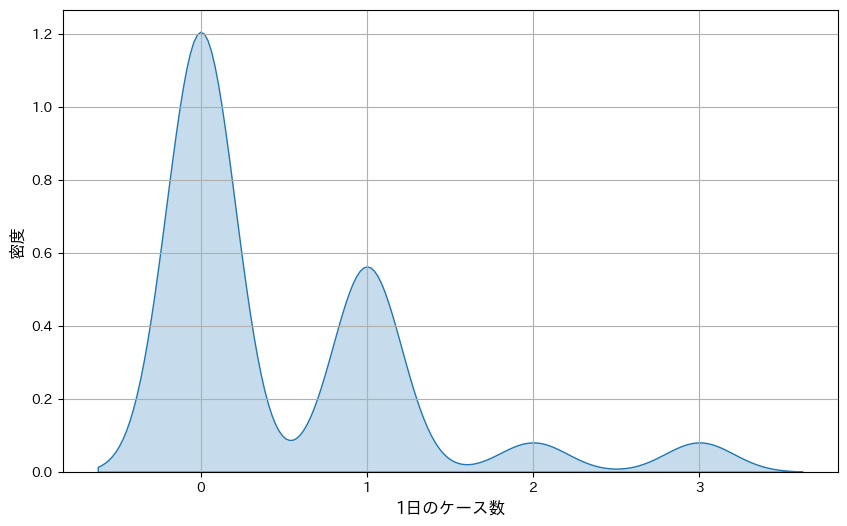

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(time_grouped.iloc[0], bw_adjust=0.5, fill=True)
plt.xlabel('1日のケース数', fontsize=12)
plt.ylabel('密度', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
neighbor_keys = list(predict_dicts['新宿区新宿３丁目'].keys())
df1 = pd.DataFrame([predict_dicts['新宿区新宿３丁目'][key] for key in neighbor_keys], index=neighbor_keys, columns=pd.date_range('2022-01-01', periods=365, freq='D').strftime('%Y-%m-%d'))
df1 = df1.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)
df1 = df1.apply(lambda x: x ** 10)
df1 = df1.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)

# df1 = df1.reset_index(drop=False).rename(columns={ 'index': '市区町丁' })
df1 = df1.fillna(0)

In [ ]:
crime_types = df.groupby(['市区町丁', '手口']).size().unstack(fill_value=0)
crime_types

手口,ひったくり,オートバイ盗,自動販売機ねらい,自動車盗,自転車盗,車上ねらい,部品ねらい
市区町丁,,,,,,,
新宿区上落合１丁目,0,0,0,0,11,1,0
新宿区上落合２丁目,0,0,0,0,8,0,0
新宿区上落合３丁目,0,0,0,0,7,0,1
新宿区下宮比町,0,0,0,0,1,0,0
新宿区下落合１丁目,0,0,0,0,6,1,0
...,...,...,...,...,...,...,...
豊島区高松２丁目,0,0,0,0,8,1,0
豊島区高松３丁目,0,0,0,0,2,0,0
豊島区高田１丁目,0,0,0,0,7,1,1


In [ ]:
proportions = crime_types.div(crime_types.sum(axis=1), axis=0)

<Axes: xlabel='市区町丁'>

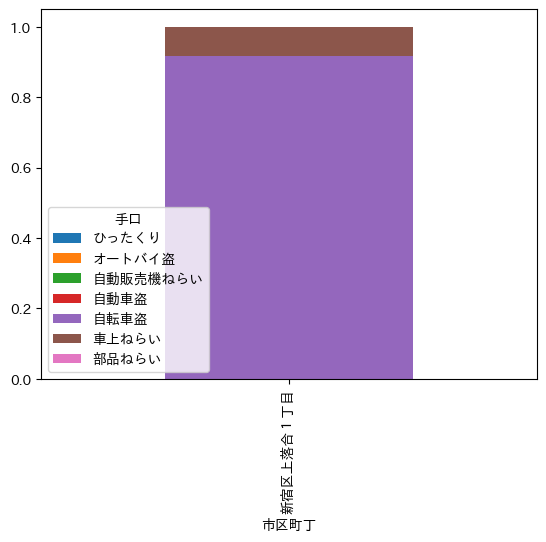

In [ ]:
proportions.iloc[[0]].plot(kind='bar', stacked=True)

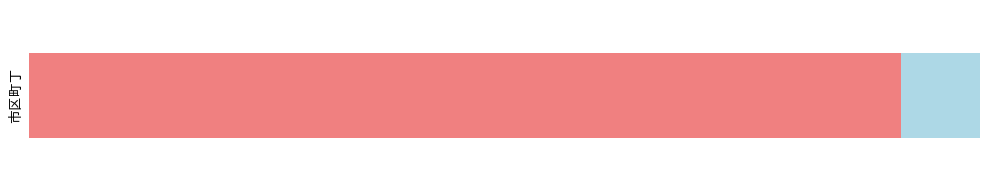

In [ ]:
fig, ax = plt.subplots(figsize=(10, 2))

# Create a horizontal stacked bar plot
proportions.iloc[[0]].plot(kind='barh', stacked=True, ax=ax, color=['lightcoral', 'lightblue', 'lightgreen', 'lightyellow'])

# Adding text labels at the center of each segment
bottom = 0
for proportion, color, label in zip(proportions.iloc[0], ['lightcoral', 'lightblue', 'lightgreen', 'lightyellow'], proportions.index):
    # ax.text(bottom + proportion / 2, 0, label, ha='center', va='center', color='black', fontsize=10)
    bottom += proportion

# Customizing the plot
ax.set_xlim(0, 1)  # Proportions scale to 1 (100%)
ax.set_yticks([])  # Remove y-ticks
ax.set_xticks([])  # Remove x-ticks
ax.spines['top'].set_visible(False)  # Remove the top spine
ax.spines['right'].set_visible(False)  # Remove the right spine
ax.spines['left'].set_visible(False)  # Remove the left spine
ax.spines['bottom'].set_visible(False)  # Remove the bottom spine
ax.legend().set_visible(False)
# Ensure the plot is displayed correctly
plt.tight_layout()
plt.show()

<Axes: xlabel='手口'>

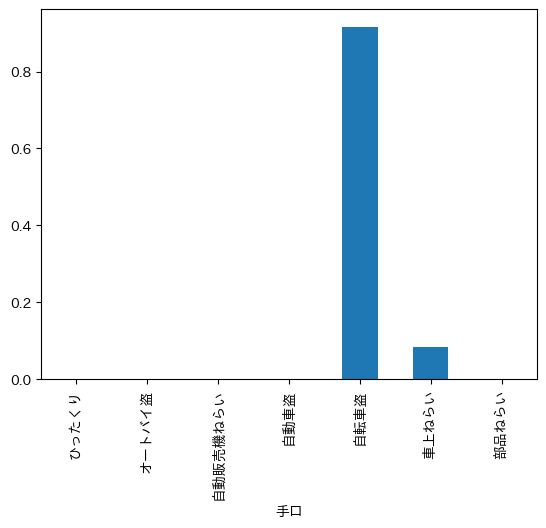

In [ ]:
proportions.iloc[0].T.plot(kind='bar', stacked=True)

In [ ]:
proportions.iloc[range(6)].T.to_dict()

{'新宿区上落合１丁目': {'ひったくり': 0.0,
  'オートバイ盗': 0.0,
  '自動販売機ねらい': 0.0,
  '自動車盗': 0.0,
  '自転車盗': 0.9166666666666666,
  '車上ねらい': 0.08333333333333333,
  '部品ねらい': 0.0},
 '新宿区上落合２丁目': {'ひったくり': 0.0,
  'オートバイ盗': 0.0,
  '自動販売機ねらい': 0.0,
  '自動車盗': 0.0,
  '自転車盗': 1.0,
  '車上ねらい': 0.0,
  '部品ねらい': 0.0},
 '新宿区上落合３丁目': {'ひったくり': 0.0,
  'オートバイ盗': 0.0,
  '自動販売機ねらい': 0.0,
  '自動車盗': 0.0,
  '自転車盗': 0.875,
  '車上ねらい': 0.0,
  '部品ねらい': 0.125},
 '新宿区下宮比町': {'ひったくり': 0.0,
  'オートバイ盗': 0.0,
  '自動販売機ねらい': 0.0,
  '自動車盗': 0.0,
  '自転車盗': 1.0,
  '車上ねらい': 0.0,
  '部品ねらい': 0.0},
 '新宿区下落合１丁目': {'ひったくり': 0.0,
  'オートバイ盗': 0.0,
  '自動販売機ねらい': 0.0,
  '自動車盗': 0.0,
  '自転車盗': 0.8571428571428571,
  '車上ねらい': 0.14285714285714285,
  '部品ねらい': 0.0},
 '新宿区下落合２丁目': {'ひったくり': 0.0,
  'オートバイ盗': 0.3333333333333333,
  '自動販売機ねらい': 0.0,
  '自動車盗': 0.0,
  '自転車盗': 0.6666666666666666,
  '車上ねらい': 0.0,
  '部品ねらい': 0.0}}

In [ ]:
results = crime_types.iloc[range(6)].T.to_dict()
results = {k: list(v.values()) for k, v in results.items()}
results

{'新宿区上落合１丁目': [0, 0, 0, 0, 11, 1, 0],
 '新宿区上落合２丁目': [0, 0, 0, 0, 8, 0, 0],
 '新宿区上落合３丁目': [0, 0, 0, 0, 7, 0, 1],
 '新宿区下宮比町': [0, 0, 0, 0, 1, 0, 0],
 '新宿区下落合１丁目': [0, 0, 0, 0, 6, 1, 0],
 '新宿区下落合２丁目': [0, 1, 0, 0, 2, 0, 0]}

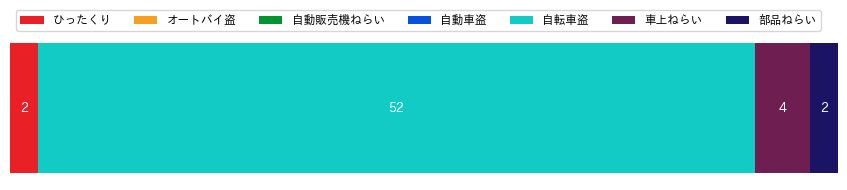

In [ ]:
import matplotlib.colors as mcolors

def hex_to_rgba(hex_str, alpha=1.0):
    rgba = mcolors.to_rgba(hex_str, alpha=alpha)
    return rgba

category_names = crime_types.columns
region = '新宿区新宿３丁目'
results = proportions.loc[[region]].T.to_dict()
results = {k: list(v.values()) for k, v in results.items()}

labels = list(results.keys())
data = np.array(list(results.values()))
data_cum = data.cumsum(axis=1)
category_colors = ['#EA2027', '#F79F1F', '#009432', '#0652DD', '#12CBC4', '#6F1E51', '#1B1464']

fig, ax = plt.subplots(figsize=(9.4, 2))
ax.invert_yaxis()
ax.xaxis.set_visible(False)
ax.set_xlim(0, np.sum(data, axis=1).max())

for i, (colname, color) in enumerate(zip(category_names, category_colors)):
    widths = data[:, i]
    starts = data_cum[:, i] - widths
    rects = ax.barh(labels, widths, left=starts, height=0.5, label=colname, color=color)

    r, g, b, _ = hex_to_rgba(color)
    text_color = 'white' if r * g * b < 0.2 else 'darkgrey'
    for j, (rect, width) in enumerate(zip(rects, widths)):
        if width > 0:
            ax.text(rect.get_x() + rect.get_width() / 2, rect.get_y() + rect.get_height() / 2,
                    f'{crime_types.loc[region, crime_types.columns[i]]}', ha='center', va='center', color=text_color, fontsize=9)

ax.legend(ncols=len(category_names), bbox_to_anchor=(0, 1), loc='lower left', fontsize='small')

# ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# ax.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
proportions.to_csv('final_data/proportions.csv')
crime_types.to_csv('final_data/crime_types.csv')

In [ ]:
proportions

手口,ひったくり,オートバイ盗,自動販売機ねらい,自動車盗,自転車盗,車上ねらい,部品ねらい
市区町丁,,,,,,,
新宿区上落合１丁目,0.0,0.0,0.000000,0.0,0.916667,0.083333,0.000000
新宿区上落合２丁目,0.0,0.0,0.000000,0.0,1.000000,0.000000,0.000000
新宿区上落合３丁目,0.0,0.0,0.000000,0.0,0.875000,0.000000,0.125000
新宿区下宮比町,0.0,0.0,0.000000,0.0,1.000000,0.000000,0.000000
新宿区下落合１丁目,0.0,0.0,0.000000,0.0,0.857143,0.142857,0.000000
...,...,...,...,...,...,...,...
豊島区高松２丁目,0.0,0.0,0.000000,0.0,0.888889,0.111111,0.000000
豊島区高松３丁目,0.0,0.0,0.000000,0.0,1.000000,0.000000,0.000000
豊島区高田１丁目,0.0,0.0,0.000000,0.0,0.777778,0.111111,0.111111


In [ ]:
p

In [ ]:
crime_types.loc['豊島区南池袋１丁目']

,豊島区南池袋１丁目
手口,
ひったくり,0
オートバイ盗,0
自動販売機ねらい,0
自動車盗,0
自転車盗,9
車上ねらい,0
部品ねらい,0


In [ ]:
crime_types.iloc[j, i]

NameError: name 'j' is not defined